In [1]:
import pandas as pd
import duckdb
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.ticker as mticker

sns.set_theme(style='whitegrid',
              palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

conn = duckdb.connect('../database/olist.db')

In [5]:
# let's check the order delivery details
query = """
    SELECT * from information_schema.tables
"""

conn.execute(query).df().head()


,table_catalog,table_schema,table_name,table_type,self_referencing_column_name,reference_generation,user_defined_type_catalog,user_defined_type_schema,user_defined_type_name,is_insertable_into,is_typed,commit_action,TABLE_COMMENT
0,olist,main,customers,BASE TABLE,None,None,None,None,None,YES,NO,None,None
1,olist,main,geoloc,BASE TABLE,None,None,None,None,None,YES,NO,None,None
2,olist,main,orders,BASE TABLE,None,None,None,None,None,YES,NO,None,None
3,olist,main,orders_delivery_details,BASE TABLE,None,None,None,None,None,YES,NO,None,None
4,olist,main,order_cost_details,BASE TABLE,None,None,None,None,None,YES,NO,None,None


# Overview

Total unique orders

In [5]:
# Total Unique orders
query = """
    SELECT COUNT(distinct order_id) as 'Total Orders'
    FROM view_orders_delivered
"""

conn.execute(query).df()


,Total Orders
0,96478


Total revenue - 16.01M

In [ ]:

query = """
    SELECT round(sum(opa.total_payment_value),2) as revenue
    FROM view_orders_delivered odd
    LEFT JOIN order_payments_agg opa
    on odd.order_id = opa.order_id
"""

conn.execute(query).df()


,revenue
0,16008872.12


Average, median review scores

In [6]:

query = """
    SELECT round(avg(ors.avg_score),2) as avg_score, round(median(ors.avg_score),2) as median_score
    FROM view_orders_delivered odd
    LEFT JOIN order_review_summary ors
    on odd.order_id = ors.order_id
"""

conn.execute(query).df()


,avg_score,median_score
0,4.16,5.0


Average, median order value

In [7]:

query = """
    SELECT round(avg(ocd.order_cost),2) as avg_value, round(median(ocd.order_cost),2) as median_value
    FROM view_orders_delivered odd
    LEFT JOIN order_cost_details ocd
    on odd.order_id = ocd.order_id
"""

conn.execute(query).df()


,avg_value,median_value
0,159.26,104.94


On-time vs Late deliveries

In [ ]:

query = """
    with on_time_calc as (
        SELECT
            *,
            CASE
                WHEN delivery_days_accuracy <=0 then 1
                else 0
            END as 'on_time'
        FROM view_orders_delivered
    )
    select 
        round(avg(on_time), 2) as timely_per,
    from on_time_calc
"""

conn.execute(query).df().head()


,timely_per
0,0.9


Average, median delivery time

In [ ]:

query = """
    SELECT
        round(avg(days_till_delivered),2) as avg_delivery_time,
        round(median(days_till_delivered),2) as median_delivery_time,
        round(mode(days_till_delivered),2) as median_delivery_time,
    FROM view_orders_delivered


"""

conn.execute(query).df().head()


,avg_delivery_time,median_delivery_time,median_delivery_time_1
0,12.5,10.0,7


Sellers

In [57]:

query = """
    SELECT
        count(distinct seller_id) as total_sellers
    FROM seller_performance


"""

conn.execute(query).df().head()


,total_sellers
0,3095


Order reviews

In [62]:

query = """
    SELECT
        sum(total_reviews_count) as total_reviews,
        sum(textual_reviews) as total_text_based,
        round(avg(avg_score),2) as avg_score
    FROM order_review_summary


"""

conn.execute(query).df().head()


,total_reviews,total_text_based,avg_score
0,99224.0,40977.0,4.09


# Analysis

### Monthly revenue

C:\Users\Tejali\AppData\Local\Temp\ipykernel_21348\3367420942.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df.resample(
C:\Users\Tejali\AppData\Local\Temp\ipykernel_21348\3367420942.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders = df.resample(


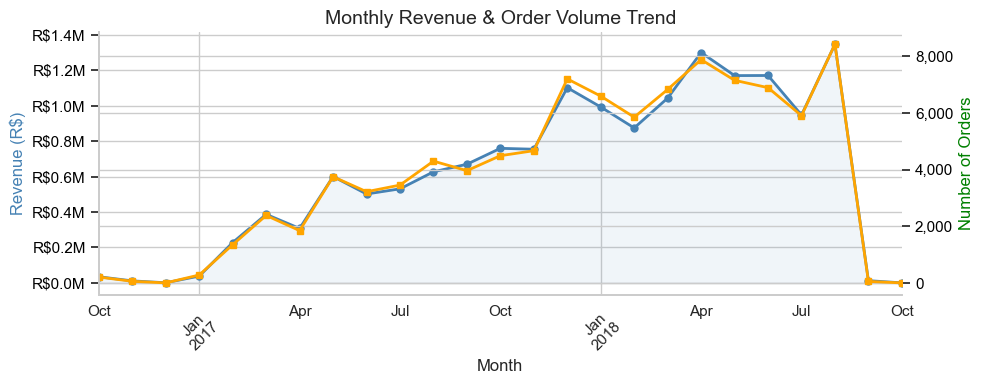

In [ ]:
query = """ 
    select
        odd.order_delivered_customer_date,  ocd.order_cost, odd.order_id
    from view_orders_delivered odd
    LEFT JOIN order_cost_details ocd
    on odd.order_id = ocd.order_id
    where odd.order_delivered_customer_date is not null
    order by odd.order_delivered_customer_date desc
    
"""

df = conn.execute(query).df()
df['order_date'] = pd.to_datetime(
    df['order_delivered_customer_date'])

monthly_revenue = df.resample(
    'M', on='order_date')['order_cost'].sum()
monthly_orders = df.resample(
    'M', on='order_date')['order_id'].count()
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
monthly_revenue.plot(ax=ax1, marker='o', color='steelblue', 
                     linewidth=2, markersize=5, label='Revenue')
monthly_orders.plot(ax=ax2, marker='s', color='orange', 
                    linewidth=2, markersize=5, label='Orders')

ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x/1_000_000:.1f}M'))
ax1.set_ylabel('Revenue (R$)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='black')

ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.set_ylabel('Number of Orders', color='green')
ax2.tick_params(axis='y', labelcolor='black')

ax1.set_title('Monthly Revenue & Order Volume Trend', fontsize=14)
ax1.set_xlabel('Month')
ax1.tick_params(axis='x', rotation=45)

ax1.fill_between(monthly_revenue.index, monthly_revenue.values,
                 alpha=0.08, color='steelblue')

plt.tight_layout()
plt.show()

Observation: The revenue and order volume broadly track together. However for months later july 2017 to somewhat oct 2017 it diverges and similarly for Jan 2018 to July 2018 it diverges as well.

Another important thing to notice is that from Dec 2017/Jan 2018 there is a significant divergence meaning, orders have been higher than the revenue that indicates one of these issues : 

    - the avergae order value had significantly increased.
    - mix of diff higher value product categories were purchased
    - small revenue of very large orders are inflating the revenue

In [ ]:
query = """ 
    select
        
        DATE_TRUNC('month', odd.order_delivered_customer_date) AS order_month,
        strftime('%B %Y', odd.order_delivered_customer_date) AS month_label,
        sum(ocd.order_cost) as total_revenue,
        count(odd.order_id) as total_orders, 
        round(avg(ocd.order_cost),2) as avg_order_value, 
        round(median(ocd.order_cost)) as med_order_value,
        round((avg(ocd.order_cost)-median(ocd.order_cost))/round(avg(ocd.order_cost),2),2) as per_diff
    from view_orders_delivered odd
    LEFT JOIN order_cost_details ocd
    on odd.order_id = ocd.order_id
    where odd.order_delivered_customer_date is not null 
        and odd.order_delivered_customer_date between '2017-01-01' AND '2018-03-31'
    GROUP BY 1, 2
    ORDER BY 1


    
"""

conn.execute(query).df()

,order_month,month_label,total_revenue,total_orders,avg_order_value,med_order_value,per_diff
0,2017-01-01,January 2017,3.869702e+04,283,136.74,77.0,0.44
1,2017-02-01,February 2017,2.280774e+05,1353,168.57,110.0,0.35
2,2017-03-01,March 2017,3.872084e+05,2385,162.35,102.0,0.37
3,2017-04-01,April 2017,3.076843e+05,1849,166.41,101.0,0.39
4,2017-05-01,May 2017,6.006392e+05,3752,160.09,103.0,0.36
5,2017-06-01,June 2017,5.020446e+05,3223,155.77,102.0,0.34
6,2017-07-01,July 2017,5.311156e+05,3456,153.68,102.0,0.34
7,2017-08-01,August 2017,6.273086e+05,4302,145.82,99.0,0.32
8,2017-09-01,September 2017,6.700356e+05,3965,168.99,103.0,0.39
9,2017-10-01,October 2017,7.598394e+05,4494,169.08,106.0,0.37


AOV remains stable around R$149–R$162 across this period. It is also observed that the median order value is consistently around 35% lower than the mean, thereby indicating a right skwed distribution driven by higher value orders. The highest order values in decmeber for this time period showcasing ~7,200 orders is could be due to the fulfillment of Black friday orders.


### Order delivery analysis

In [ ]:
query = """
    with on_time_calc as (
        SELECT
            *,
            CASE
                WHEN delivery_days_accuracy <=0 then 1
                else 0
            END as 'on_time'
        FROM view_orders_delivered
    )
    select 
        round(avg(on_time), 2) as timely_per, round(1-timely_per,2) as late_per
    from on_time_calc
"""

df = conn.execute(query).df().head()
data = df.values()
labels = df.keys()

colors = sns.color_palette('pastel')
plt.pie(data, labels=labels, colors = colors, autopct='%1.1f%%',
        startangle=140, wedgeprops={'width':0.4})
plt.title('Donut chart example')
plt.show()

To check if delivery is distirbuted or concentrated across states

In [20]:
query = """
    with delivery_distribution as (
        with on_time_calc as (
            SELECT
                *,
                CASE
                    WHEN delivery_days_accuracy <=0 then 1
                    else 0
                END as 'on_time'
            FROM view_orders_delivered
        )
        select 
            otc.order_id, otc.customer_id,  c.customer_state, c.customer_city,
            days_till_estim_delivery, days_till_delivered,
            round(abs(days_till_estim_delivery - days_till_delivered)/days_till_delivered,2) as delay_per,
            avg_score, total_reviews_count
        from on_time_calc otc
        
        LEFT JOIN order_review_summary ors
        on otc.order_id = ors.order_id
        LEFT JOIN customers c
        on otc.customer_id = c.customer_id
        where on_time = 0
    ),
    overview as (
        select c.customer_state,
            count(vod.order_id) as total_orders_delivered
        from  view_orders_delivered vod
        LEFT JOIN customers c
        on vod.customer_id = c.customer_id
        group by c.customer_state
    )
    select 
        dd.customer_state,
        round(avg(delay_per)*100, 2) as avg_delay_per,
        count(order_id) as late_orders, 
        total_orders_delivered,
        round(late_orders*100/total_orders_delivered,2) as late_order_per,
        
        count(customer_id) as customers,
        round(avg(days_till_delivered),2) as avg_days_delivered,
        round(median(days_till_delivered),2) as median_days_delivered,
        
        round(avg(avg_score), 2) as avg_socre,
        round(median(avg_score), 2) as median_socre,
        round(mode(avg_score), 2) as mode_socre
    from delivery_distribution dd
    LEFT JOIN overview as o
    on dd.customer_state = o.customer_state
    group by dd.customer_state, total_orders_delivered
    order by late_order_per desc
"""

conn.execute(query).df()

,customer_state,avg_delay_per,late_orders,total_orders_delivered,late_order_per,customers,avg_days_delivered,median_days_delivered,avg_socre,median_socre,mode_socre
0,AL,21.09,85,397,21.41,85,40.73,38.0,2.13,1.0,1.0
1,MA,23.94,125,717,17.43,125,37.01,34.0,2.18,1.0,1.0
2,SE,27.02,51,335,15.22,51,44.78,37.0,1.94,1.0,1.0
3,PI,23.77,66,476,13.87,66,39.91,33.0,2.26,1.0,1.0
4,CE,28.60,176,1279,13.76,176,44.42,40.0,2.04,1.0,1.0
5,RR,30.40,5,41,12.20,5,84.80,71.0,1.80,1.0,1.0
6,BA,24.43,396,3256,12.16,396,39.38,35.0,2.36,1.0,1.0
7,RJ,30.51,1495,12350,12.11,1495,37.88,35.0,1.91,1.0,1.0
8,PA,22.52,106,946,11.21,106,48.57,45.5,1.92,1.0,1.0
9,ES,25.55,214,1995,10.73,214,34.54,30.0,2.51,2.0,1.0


It is observed that most of these orders were marked with low ratings.

### Sales

C:\Users\Tejali\AppData\Local\Temp\ipykernel_10300\2537364049.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


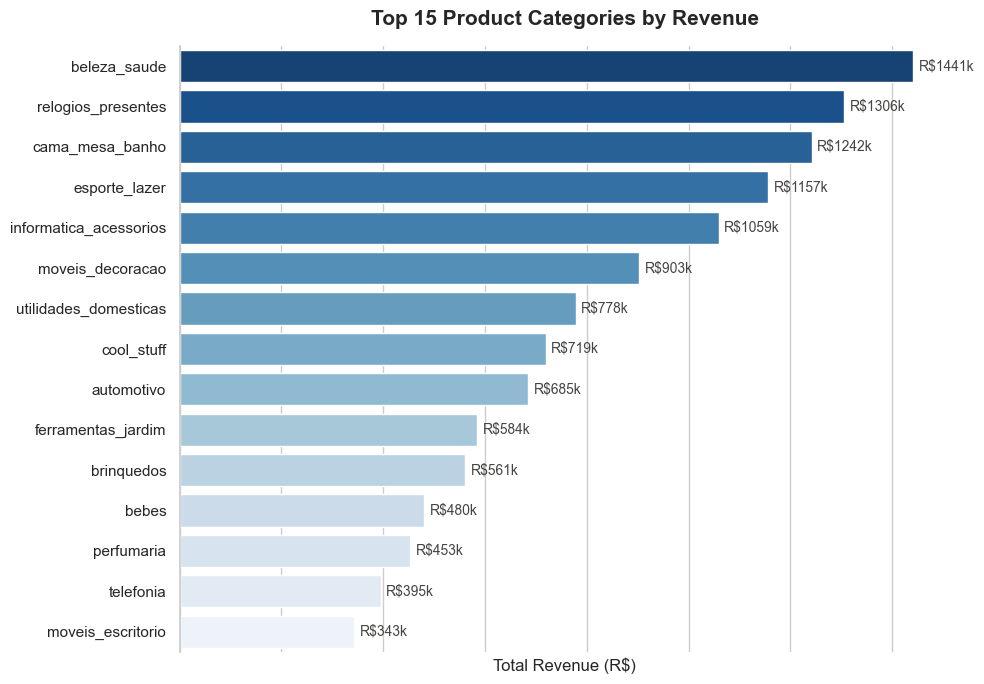

In [11]:
# Top product categories based on revenue

query =""" 
    select p.product_category_name, sum(sp.cost_total) as revenue
    from products p
    LEFT JOIN seller_performance sp
    on p.product_id = sp.product_id
    group by p.product_category_name
    order by revenue desc
    LIMIT 15

"""
df = conn.execute(query).df()

fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(
    data=df,
    x='revenue',
    y='product_category_name',
    palette='Blues_r',
    ax=ax
)

# ── Formatting ────────────────────────────────────────
ax.set_title('Top 15 Product Categories by Revenue', 
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (R$)', fontsize=12)
ax.set_ylabel('')

# Format x-axis as currency
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'R${x/1_000:.0f}k')
)

# Add value labels on each bar
for container in ax.containers:
    ax.bar_label(container,
                 fmt=lambda x: f'R${x/1_000:.0f}k',
                 padding=4,
                 fontsize=10,
                 color='#444441')

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

plt.tight_layout()
plt.show()

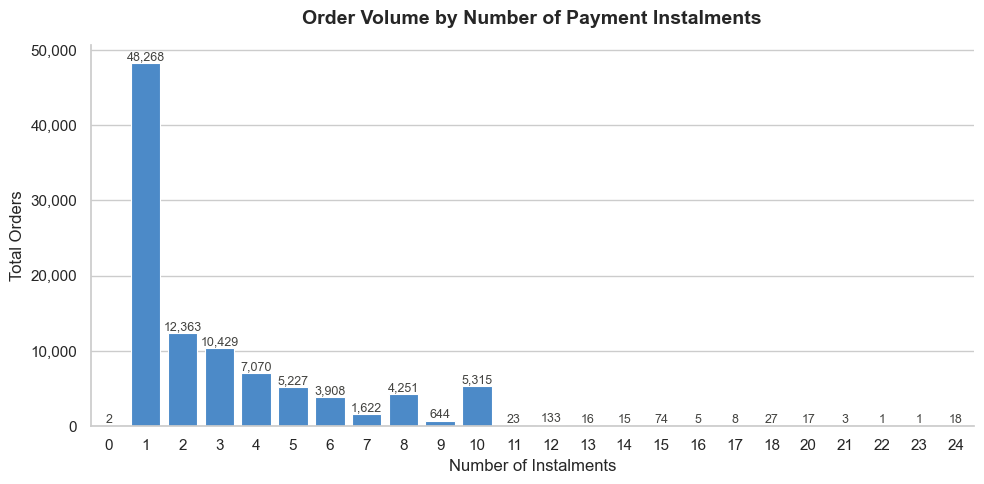

In [15]:
# Installment choice

query =""" 
    select 
        max_pay_install, count(distinct order_id) as total_orders
    from order_payments_agg
    group by max_pay_install
    order by max_pay_install

"""
df = conn.execute(query).df()

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=df.sort_values('max_pay_install'),
    x="max_pay_install",
    y="total_orders",
    color='#378ADD',
    edgecolor='white',
    linewidth=0.8,
    ax=ax
)
ax.set_title('Order Volume by Number of Payment Instalments', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Instalments', fontsize=12)
ax.set_ylabel('Total Orders', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# value labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, color='#444441')

sns.despine()
plt.tight_layout()
plt.show()

# Seller performance

In [19]:
query = """ 
    select 
        *
    from seller_performance
"""
conn.execute(query).df().head()

,seller_id,product_id,order_id,orders_total,across_products,price_value,freight_value,cost_total,shipping_burden
0,92eb0f42c21942b6552362b9b114707d,23365beed316535b4105bd800c46670e,0014ae671de39511f7575066200733b7,1,1,16.50,14.10,30.60,14.9545
1,955fee9216a65b617aa5c0531780ce60,35537536ed2b4c561b4018bf3abf54e0,0025c5d1a8ca53a240ec2634bb4492ea,1,1,390.00,29.39,419.39,29.4654
2,7c67e1448b00f6e969d365cea6b010ab,4c1bbc12438daec98a77243c2bf7a3ba,0036757472ece3dde52fd4bfd929c90e,1,1,136.99,66.04,203.03,66.5221
3,f80edd2c5aaa505cc4b0a3b219abf4b8,452f66a0f164cac57802e2cea93188ac,003a94f778ef8cfd50247c8c1b582257,1,1,39.90,18.08,57.98,18.5331
4,7210cd29727d674c00741e5e387b3ccd,0c4a0f8ab44f9acd2d04e7024f9ba362,00526a9d4ebde463baee25f386963ddc,1,1,135.56,33.60,169.16,34.5914


In [11]:
query = """ 
    select 
        seller_id, count(order_id) as total_orders
    from seller_performance
    group by seller_id
"""
conn.execute(query).df().head()

,seller_id,total_orders
0,f80edd2c5aaa505cc4b0a3b219abf4b8,120
1,c4fb51fb1c5b7c07bc5e67be6e7e8f6e,15
2,9f505651f4a6abe901a56cdc21508025,398
3,ef30892870c278497523264be1be2241,9
4,e62b2d6ac10570a035a30bafcf01d263,63


In [17]:
query = """ 
    with agg_sellerp as(
        select 
            seller_id, count(order_id) as total_orders
        from seller_performance
        group by seller_id
    )
    select round(avg(total_orders),2), median(total_orders), mode(total_orders) from agg_sellerp
"""
conn.execute(query).df().head()

,"round(avg(total_orders), 2)",median(total_orders),"""mode""(total_orders)"
0,33.09,7.0,1


The total orders per seller is concentrated more towards right as mean > median.

### Working with the pareto principle
Is this data concentrated? Is 80% of orders provided by 20% of sellers?

In [ ]:
query = """ 
    select * from seller_aggregated
"""

conn.execute(query).df()

,seller_id,total_orders,total_cost,pct_orders,cumulative_pct
0,6560211a19b47992c3666cc44a7e94c0,1982,151265.77,2.0,1.94
1,4a3ca9315b744ce9f8e9374361493884,1889,235539.96,2.0,3.78
2,cc419e0650a3c5ba77189a1882b7556a,1720,129957.41,2.0,5.46
3,1f50f920176fa81dab994f9023523100,1473,142104.98,1.0,6.90
4,da8622b14eb17ae2831f4ac5b9dab84a,1438,185192.32,1.0,8.30
...,...,...,...,...,...
3090,57a834594e1e9e9219603bfec184eadc,1,166.05,0.0,100.00
3091,9ac75591b69c3402684b6ce0310f22ee,1,69.67,0.0,100.00
3092,578460d8319c51dab351cd9db95eadfe,1,270.45,0.0,100.00
3093,4450bd8327d471c4a11a83d1445b1b62,1,214.56,0.0,100.00


In [ ]:
query = """ 

    select count(seller_id) from seller_aggregated
    where cumulative_pct < =50
"""
conn.execute(query).df()

,count(seller_id)
0,128


So from 3,095 sellers 128 of them contribute towards 50% of ours orders. Which is bit concerning and confirms that the order levels are concentrated for these sellers.

In [ ]:
query = """ 
    create or replace view seller_concentrated as
    select * from seller_aggregated
    where cumulative_pct <=80
"""
conn.execute(query)

In [ ]:
query = """ 
    create or replace view seller_concentrated_reviews as
    with seller_concentrated as (
        select * from seller_aggregated
        where cumulative_pct <=80
    ),
    seller_reviews as (
        select 
            seller_id, sc.order_id,orders_total, cost_total, shipping_burden,
            review_score, 
        from seller_performance sc
        LEFT JOIN order_reviews ord
        on sc.order_id = ord.order_id
    )
    select
        sc.seller_id, sc.total_orders, round((sc.total_cost),2) as total_cost, sc.pct_orders, sc.cumulative_pct,
        round(avg(sr.review_score),2)  as avg_score
    from seller_concentrated sc
    LEFT JOIN seller_reviews sr
    on sc.seller_id = sr.seller_id
    group by sc.seller_id, sc.total_orders, sc.total_cost, sc.pct_orders, sc.cumulative_pct,
"""
conn.execute(query)

In [80]:
query = """ 
    
    select
        *
    from seller_concentrated_reviews
    order by total_orders desc LIMIT 10
"""
conn.execute(query).df()

,seller_id,total_orders,total_cost,pct_orders,cumulative_pct,avg_score
0,6560211a19b47992c3666cc44a7e94c0,1982,151265.77,2.0,1.94,3.92
1,4a3ca9315b744ce9f8e9374361493884,1889,235539.96,2.0,3.78,3.82
2,cc419e0650a3c5ba77189a1882b7556a,1720,129957.41,2.0,5.46,4.07
3,1f50f920176fa81dab994f9023523100,1473,142104.98,1.0,6.90,4.11
4,da8622b14eb17ae2831f4ac5b9dab84a,1438,185192.32,1.0,8.30,4.10
5,955fee9216a65b617aa5c0531780ce60,1290,160602.68,1.0,9.56,4.16
6,ea8482cd71df3c1969d7b9473ff13abc,1169,54722.29,1.0,10.70,3.97
7,7a67c85e85bb2ce8582c35f2203ad736,1166,162648.38,1.0,11.84,4.24
8,4869f7a5dfa277a7dca6462dcf3b52b2,1143,249640.70,1.0,12.96,4.13
9,3d871de0142ce09b7081e2b9d1733cb1,1125,117347.71,1.0,14.05,4.13


Since, 531 out of 3095 which makes almost 17% of sellers that contribute towards 80% of our orders. Which means, if top 5-10 sellers stopped contributing and left, upto 10-15% of our sales will be gone with them.

In [86]:
# Analysing the review scenario for these sellers.
query = """ 
    
    select
        round(avg(avg_score),2), median(avg_score), max(avg_score), min(avg_score)
    from seller_concentrated_reviews
"""
conn.execute(query).df()

,"round(avg(avg_score), 2)",median(avg_score),max(avg_score),min(avg_score)
0,4.1,4.15,4.82,2.31


In [90]:
# % of sellers with less than the avg review score of 3.5
query = """ 
    with total_sellers as (
        select sum(total_orders) as total_orders
        from seller_concentrated_reviews
    ),
    sellers_3_5_less as (
        select sum(total_orders) as seller_low_score_orders
        from seller_concentrated_reviews
        where avg_score <=3.5
    )
    select
        seller_low_score_orders*100/total_orders
    from total_sellers, sellers_3_5_less
    
"""
conn.execute(query).df()

,((seller_low_score_orders * 100) / total_orders)
0,3.849441


Almost 4% of orders make up the sellers with avg reviews less than 3.5

### Exploring other 20% of sellers

In [149]:
query = """ 
    create or replace view other_seller_reviews as
    with other_sellers as (
        select
            *
        from pareto_principle 
        where cumulative_pct > 80
    ),
    total_orders as (
        select sum(orders_total) as total_ord from seller_performance
    ),
    total_orders_other as (
        select sum(total_orders) as total_ordo from other_sellers
    ),
    get_reviews as (
        select
            sp.seller_id, 
            count(product_id) as total_products, 
            round(sum(price_value),2) as price_value, 
            round(sum(freight_value),2) as freight_value,
            count(review_id) as review_count,
            round(avg(review_score),2) as avg_review_score
        from seller_performance sp
        LEFT JOIN order_reviews ordr
        on sp.order_id = ordr.order_id
        group by sp.seller_id
    ),
    other_reviews as (
        select 
            *            
        from other_sellers osr
        LEFT JOIN get_reviews gr
        on osr.seller_id = gr.seller_id
        
    )
    select 
        seller_id, total_orders, round(total_cost,2) as total_cost, cumulative_pct, 
        total_products, price_value, freight_value, review_count, avg_review_score as avg_rscore
    from other_reviews
    
"""

conn.execute(query)

In [150]:
conn.execute("""select * from other_seller_reviews""").df()

,seller_id,total_orders,total_cost,cumulative_pct,total_products,price_value,freight_value,review_count,avg_rscore
0,9853a239ab7b7ebbdc3a21248d5b8e1f,5,471.01,97.51,5,381.00,90.01,5,3.80
1,6426d21aca402a131fc0a5d0960a3c90,23,1593.82,86.56,23,1209.64,384.18,23,4.17
2,2e3be8a987a30d7544dbbda6861cc14e,18,4777.55,89.13,18,4430.84,346.71,18,3.17
3,b1b3948701c5c72445495bd161b83a4c,18,25185.49,89.13,18,24699.19,486.30,18,1.72
4,fde0cc9ea29c8ccfc0a2c22256a58c71,35,4921.27,81.53,35,3922.00,999.27,35,4.49
...,...,...,...,...,...,...,...,...,...
2559,2cb98e27ce1c18abdb42209b34c382a7,1,119.70,100.00,1,62.49,57.21,1,4.00
2560,3e35a8bb43569389d3cebef0ce820f69,1,84.68,100.00,1,55.80,28.88,1,5.00
2561,1746c1ae87ac63d530c7c943d0ac42e2,1,252.35,100.00,1,229.90,22.45,1,5.00
2562,3820c6537b3853be1a0687d5a60807ec,1,35.96,100.00,1,25.00,10.96,0,NaN


In [151]:
# Avg review for these sellers
conn.execute("""select avg(avg_rscore), median(avg_rscore), min(avg_rscore), max(avg_rscore) from other_seller_reviews""").df()

,avg(avg_rscore),median(avg_rscore),min(avg_rscore),max(avg_rscore)
0,3.973283,4.21,1.0,5.0


In [171]:
conn.execute("""
             select  
                case
                    when (avg_rscore >= 0 and avg_rscore < 3) then 'Poor'
                    when (avg_rscore >=3 and avg_rscore < 3.75) then 'Not bad'
                    when (avg_rscore >=3.75 and avg_rscore < 4.5) then 'Good'
                    when  (avg_rscore >=4.5 and avg_rscore <=5) then 'Best'
                    else 'NA'
                end as rating,
                count(seller_id) as seller_count,
                sum(total_orders) as order_count
             from other_seller_reviews 
             group by rating
             order by seller_count desc""").df()

,rating,seller_count,order_count
0,Best,941,4821.0
1,Good,927,11766.0
2,Not bad,387,2989.0
3,Poor,304,936.0
4,NA,5,5.0


In [172]:
conn.close()